# **01. Install/import libraries**

In [ ]:
# Install required libraries
!pip install -q joblib

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully!")

Libraries imported successfully!


# **02. Load dataset**

In [21]:
df = pd.read_csv("SriLanka_Weather_Dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (147480, 24)


,time,weathercode,temperature_2m_max,temperature_2m_min,temperature_2m_mean,apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,sunrise,sunset,shortwave_radiation_sum,precipitation_sum,rain_sum,snowfall_sum,precipitation_hours,windspeed_10m_max,windgusts_10m_max,winddirection_10m_dominant,et0_fao_evapotranspiration,latitude,longitude,elevation,country,city
0,2010-01-01,2,30.0,22.7,26.1,34.4,25.2,29.2,2010-01-01T00:52,2010-01-01T12:35,20.92,0.0,0.0,0.0,0.0,11.7,27.4,20,4.58,7.0,79.899994,16.0,Sri Lanka,Colombo
1,2010-01-02,51,29.9,23.5,26.2,33.8,26.2,29.8,2010-01-02T00:52,2010-01-02T12:36,17.71,0.1,0.1,0.0,1.0,13.0,27.0,24,3.84,7.0,79.899994,16.0,Sri Lanka,Colombo
2,2010-01-03,51,29.5,23.2,26.0,34.3,26.3,29.9,2010-01-03T00:53,2010-01-03T12:36,17.76,0.6,0.6,0.0,3.0,12.3,27.4,16,3.65,7.0,79.899994,16.0,Sri Lanka,Colombo
3,2010-01-04,2,28.9,21.9,25.3,31.6,23.4,27.8,2010-01-04T00:53,2010-01-04T12:37,16.50,0.0,0.0,0.0,0.0,17.0,34.6,356,3.79,7.0,79.899994,16.0,Sri Lanka,Colombo
4,2010-01-05,1,28.1,21.3,24.5,30.1,23.1,26.1,2010-01-05T00:53,2010-01-05T12:37,23.61,0.0,0.0,0.0,0.0,18.7,37.1,355,4.97,7.0,79.899994,16.0,Sri Lanka,Colombo


# **03. Basic dataset information**

In [22]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
for i, col in enumerate(df.columns, 1):
    print(i, "-", col)

Number of rows: 147480
Number of columns: 24

Column names:
1 - time
2 - weathercode
3 - temperature_2m_max
4 - temperature_2m_min
5 - temperature_2m_mean
6 - apparent_temperature_max
7 - apparent_temperature_min
8 - apparent_temperature_mean
9 - sunrise
10 - sunset
11 - shortwave_radiation_sum
12 - precipitation_sum
13 - rain_sum
14 - snowfall_sum
15 - precipitation_hours
16 - windspeed_10m_max
17 - windgusts_10m_max
18 - winddirection_10m_dominant
19 - et0_fao_evapotranspiration
20 - latitude
21 - longitude
22 - elevation
23 - country
24 - city


# **04. Check missing values**

In [23]:
missing_values = df.isnull().sum()

print("Missing values:")
display(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("No missing values found!")

Missing values:


,0


No missing values found!


# **05. Check duplicate rows**

In [24]:
duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


# **06. Check data types**

In [25]:
print(df.dtypes)

time                           object
weathercode                     int64
temperature_2m_max            float64
temperature_2m_min            float64
temperature_2m_mean           float64
apparent_temperature_max      float64
apparent_temperature_min      float64
apparent_temperature_mean     float64
sunrise                        object
sunset                         object
shortwave_radiation_sum       float64
precipitation_sum             float64
rain_sum                      float64
snowfall_sum                  float64
precipitation_hours           float64
windspeed_10m_max             float64
windgusts_10m_max             float64
winddirection_10m_dominant      int64
et0_fao_evapotranspiration    float64
latitude                      float64
longitude                     float64
elevation                     float64
country                        object
city                           object
dtype: object


# **07. Convert date column**

In [26]:
df['time'] = pd.to_datetime(
    df['time'],
    format='mixed',
    errors='coerce'
)

print("Date conversion completed.")
print("Date range:")
print(df['time'].min(), "to", df['time'].max())

Date conversion completed.
Date range:
2010-01-01 00:00:00 to 2023-06-17 00:00:00


# **08. Sort correctly**

In [27]:
df = df.sort_values(
    ['city', 'time']
).reset_index(drop=True)

print("Data sorted by city and date.")
display(df[['city', 'time']].head(10))

Data sorted by city and date.


,city,time
0,Athurugiriya,2010-01-01
1,Athurugiriya,2010-01-02
2,Athurugiriya,2010-01-03
3,Athurugiriya,2010-01-04
4,Athurugiriya,2010-01-05
5,Athurugiriya,2010-01-06
6,Athurugiriya,2010-01-07
7,Athurugiriya,2010-01-08
8,Athurugiriya,2010-01-09
9,Athurugiriya,2010-01-10


# **09. Check Cities**

In [28]:
print("Number of cities:", df['city'].nunique())

print("\nCities:")
print(sorted(df['city'].unique()))

Number of cities: 30

Cities:
['Athurugiriya', 'Badulla', 'Bentota', 'Colombo', 'Galle', 'Gampaha', 'Hambantota', 'Hatton', 'Jaffna', 'Kalmunai', 'Kalutara', 'Kandy', 'Kesbewa', 'Kolonnawa', 'Kurunegala', 'Mabole', 'Maharagama', 'Mannar', 'Matale', 'Matara', 'Moratuwa', 'Mount Lavinia', 'Negombo', 'Oruwala', 'Pothuhera', 'Puttalam', 'Ratnapura', 'Sri Jayewardenepura Kotte', 'Trincomalee', 'Weligama']


# **10. Check rainfall columns**


In [29]:
print("Checking precipitation_sum and rain_sum...")

comparison = df[['precipitation_sum', 'rain_sum']].describe()
display(comparison)

print(
    "\nAre precipitation_sum and rain_sum identical?",
    df['precipitation_sum'].equals(df['rain_sum'])
)

Checking precipitation_sum and rain_sum...


,precipitation_sum,rain_sum
count,147480.000000,147480.000000
mean,5.975637,5.975637
std,10.215294,10.215294
min,0.000000,0.000000
25%,0.400000,0.400000
50%,2.600000,2.600000
75%,7.500000,7.500000
max,338.800000,338.800000



Are precipitation_sum and rain_sum identical? True


# **11. Rainfall distribution**

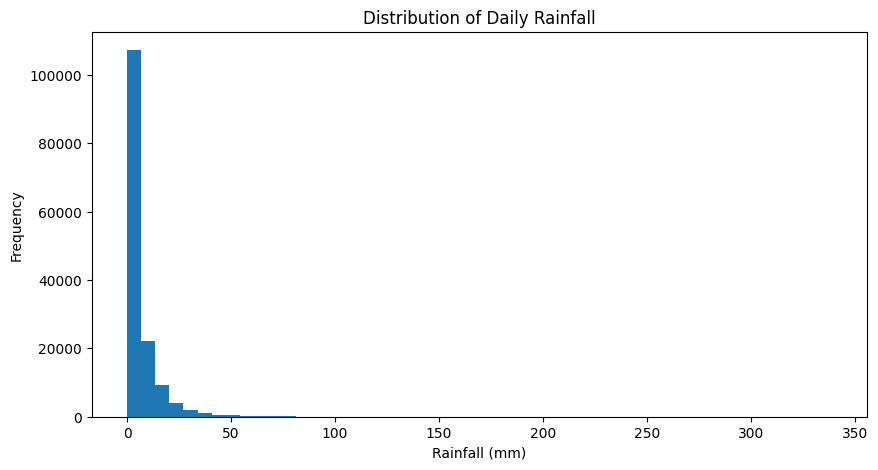

In [30]:
plt.figure(figsize=(10, 5))

plt.hist(
    df['rain_sum'],
    bins=50
)

plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.title("Distribution of Daily Rainfall")

plt.show()

# **12. Rain vs no rain**



Rain / No Rain distribution:
No Rain: 26727
Rain: 120753


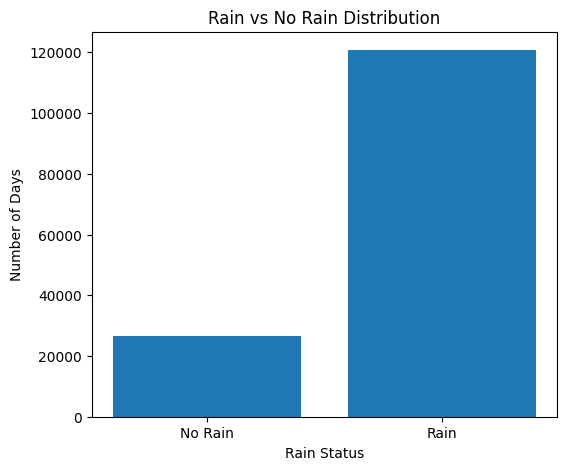

In [31]:
rain_counts = df['rain_sum'].gt(0).value_counts()

print("Rain / No Rain distribution:")

print("No Rain:", rain_counts.get(False, 0))
print("Rain:", rain_counts.get(True, 0))

plt.figure(figsize=(6, 5))

plt.bar(
    ['No Rain', 'Rain'],
    [
        rain_counts.get(False, 0),
        rain_counts.get(True, 0)
    ]
)

plt.xlabel("Rain Status")
plt.ylabel("Number of Days")
plt.title("Rain vs No Rain Distribution")

plt.show()

# **13. Basic rainfall statistics**

In [32]:
print("Rainfall statistics:")

print("Minimum:", df['rain_sum'].min(), "mm")
print("Maximum:", df['rain_sum'].max(), "mm")
print("Mean:", df['rain_sum'].mean(), "mm")
print("Median:", df['rain_sum'].median(), "mm")
print("Standard deviation:", df['rain_sum'].std(), "mm")

Rainfall statistics:
Minimum: 0.0 mm
Maximum: 338.8 mm
Mean: 5.975637374559262 mm
Median: 2.6 mm
Standard deviation: 10.215293500431146 mm


# **14. Feature Engineering**

In [33]:
# -----------------------------------------
# 1. MONTH
# -----------------------------------------

df['month'] = df['time'].dt.month


# -----------------------------------------
# 2. SEASON
# -----------------------------------------

def get_season(month):

    if month in [12, 1, 2]:
        return 1       # Northeast Monsoon

    elif month in [3, 4, 5]:
        return 2       # First Inter-monsoon

    elif month in [6, 7, 8, 9]:
        return 3       # Southwest Monsoon

    else:
        return 4       # Second Inter-monsoon


df['season'] = df['month'].apply(get_season)


# -----------------------------------------
# 3. PREVIOUS 7-DAY RAINFALL
# -----------------------------------------

df['rolling_rainfall'] = (
    df.groupby('city')['rain_sum']
      .transform(
          lambda x: x.shift(1)
                    .rolling(window=7, min_periods=1)
                    .sum()
      )
)


# -----------------------------------------
# 4. PREVIOUS-DAY RAINFALL
# -----------------------------------------

df['rainfall_lag_1'] = (
    df.groupby('city')['rain_sum']
      .shift(1)
)


# -----------------------------------------
# 5. TEMPERATURE CHANGE
# -----------------------------------------

df['temp_diff'] = (
    df.groupby('city')['temperature_2m_mean']
      .diff()
)


# -----------------------------------------
# 6. WIND-SPEED CHANGE
# -----------------------------------------

df['wind_change'] = (
    df.groupby('city')['windspeed_10m_max']
      .diff()
)


# -----------------------------------------
# 7. TEMPERATURE INTERACTION
# -----------------------------------------

df['temp_apparent_temp_interaction'] = (
    df['temperature_2m_mean']
    * df['apparent_temperature_mean']
)


# -----------------------------------------
# 8. WIND CATEGORY
# -----------------------------------------

df['wind_category'] = pd.cut(
    df['windspeed_10m_max'],
    bins=[-1, 10, 20, 100],
    labels=[0, 1, 2]
).astype(int)


print("Feature engineering completed!")

Feature engineering completed!


# **15. Handle first-day engineered values**

In [34]:
engineered_columns = [
    'rolling_rainfall',
    'rainfall_lag_1',
    'temp_diff',
    'wind_change'
]

df[engineered_columns] = df[engineered_columns].fillna(0)

print("Engineered missing values handled.")

Engineered missing values handled.


# **16. Create prediction targets**

In [35]:
# Tomorrow's rain amount
df['rainfall_amount_tomorrow'] = (
    df.groupby('city')['rain_sum']
      .shift(-1)
)


# Tomorrow rain YES/NO
df['rain_tomorrow'] = (
    df['rainfall_amount_tomorrow'] > 0
).astype(int)


print("Prediction targets created.")

Prediction targets created.


# **17. Remove final day of each city**

In [36]:
before = len(df)

df = df.dropna(
    subset=['rainfall_amount_tomorrow']
).reset_index(drop=True)

after = len(df)

print("Rows before:", before)
print("Rows after:", after)
print("Rows removed:", before - after)

Rows before: 147480
Rows after: 147450
Rows removed: 30


# **18. Check target distribution**

In [37]:
print("Classification target distribution:")

print(
    df['rain_tomorrow']
    .value_counts()
    .sort_index()
)

print("\nPercentage:")

print(
    df['rain_tomorrow']
    .value_counts(normalize=True)
    .sort_index() * 100
)

Classification target distribution:
rain_tomorrow
0     26702
1    120748
Name: count, dtype: int64

Percentage:
rain_tomorrow
0    18.10919
1    81.89081
Name: proportion, dtype: float64


# **19. Define features**

In [38]:
feature_cols = [
    'temperature_2m_mean',
    'temperature_2m_max',
    'temperature_2m_min',
    'apparent_temperature_mean',
    'windspeed_10m_max',
    'windgusts_10m_max',
    'winddirection_10m_dominant',
    'precipitation_hours',

    # Location
    'latitude',
    'longitude',
    'elevation',

    # Engineered features
    'month',
    'season',
    'rolling_rainfall',
    'rainfall_lag_1',
    'temp_diff',
    'wind_change',
    'temp_apparent_temp_interaction',
    'wind_category'
]

print("Number of features:", len(feature_cols))

print("\nFeatures:")
for feature in feature_cols:
    print("-", feature)

Number of features: 19

Features:
- temperature_2m_mean
- temperature_2m_max
- temperature_2m_min
- apparent_temperature_mean
- windspeed_10m_max
- windgusts_10m_max
- winddirection_10m_dominant
- precipitation_hours
- latitude
- longitude
- elevation
- month
- season
- rolling_rainfall
- rainfall_lag_1
- temp_diff
- wind_change
- temp_apparent_temp_interaction
- wind_category


# **20. Create X and y**

In [39]:
X = df[feature_cols]

y_class = df['rain_tomorrow']

y_reg = df['rainfall_amount_tomorrow']

print("X shape:", X.shape)
print("Classification target shape:", y_class.shape)
print("Regression target shape:", y_reg.shape)

X shape: (147450, 19)
Classification target shape: (147450,)
Regression target shape: (147450,)


# **21. Chronological train/test**

In [40]:
# Get unique dates
unique_dates = np.sort(
    df['time'].unique()
)

# 80% date cutoff
split_index = int(
    len(unique_dates) * 0.80
)

cutoff_date = unique_dates[split_index]

print("Training until:", cutoff_date)

Training until: 2020-10-07T00:00:00.000000000


# **22. Split data**

In [41]:
train_mask = df['time'] < cutoff_date
test_mask = df['time'] >= cutoff_date

X_train = X.loc[train_mask]
X_test = X.loc[test_mask]

y_c_train = y_class.loc[train_mask]
y_c_test = y_class.loc[test_mask]

y_r_train = y_reg.loc[train_mask]
y_r_test = y_reg.loc[test_mask]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining date range:")
print(df.loc[train_mask, 'time'].min())
print(df.loc[train_mask, 'time'].max())

print("\nTesting date range:")
print(df.loc[test_mask, 'time'].min())
print(df.loc[test_mask, 'time'].max())

Training samples: 117960
Testing samples: 29490

Training date range:
2010-01-01 00:00:00
2020-10-06 00:00:00

Testing date range:
2020-10-07 00:00:00
2023-06-16 00:00:00


# **23. Classification: Logistic Regression**

In [42]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logistic_model.fit(
    X_train,
    y_c_train
)

print("Logistic Regression trained!")

Logistic Regression trained!


# **24. Classification: Random Forest**

In [43]:
from sklearn.ensemble import RandomForestClassifier

rf_classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_classifier.fit(
    X_train,
    y_c_train
)

print("Random Forest Classifier trained!")

Random Forest Classifier trained!


# **25. Classification: Gradient Boosting**

In [44]:
from sklearn.ensemble import GradientBoostingClassifier

gb_classifier = GradientBoostingClassifier(
    n_estimators=100,
    random_state=42
)

gb_classifier.fit(
    X_train,
    y_c_train
)

print("Gradient Boosting Classifier trained!")

Gradient Boosting Classifier trained!


# **26. Evaluate classification models**

In [45]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

classification_models = {
    'Logistic Regression': logistic_model,
    'Random Forest': rf_classifier,
    'Gradient Boosting': gb_classifier
}

classification_results = []

for name, model in classification_models.items():

    predictions = model.predict(X_test)

    probabilities = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(
        y_c_test,
        predictions
    )

    precision = precision_score(
        y_c_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_c_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_c_test,
        predictions,
        zero_division=0
    )

    auc = roc_auc_score(
        y_c_test,
        probabilities
    )

    classification_results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC-AUC': auc
    })

classification_results_df = pd.DataFrame(
    classification_results
)

display(
    classification_results_df
    .sort_values('F1 Score', ascending=False)
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Gradient Boosting,0.887386,0.928957,0.941278,0.935077,0.900559
1,Random Forest,0.884368,0.924508,0.942774,0.933552,0.891604
0,Logistic Regression,0.883655,0.928318,0.937343,0.932808,0.896204


# **27. Classification report for Random Forest**

In [46]:
from sklearn.metrics import classification_report

rf_predictions = rf_classifier.predict(X_test)

print(
    classification_report(
        y_c_test,
        rf_predictions,
        target_names=['No Rain', 'Rain']
    )
)

              precision    recall  f1-score   support

     No Rain       0.59      0.52      0.55      4082
        Rain       0.92      0.94      0.93     25408

    accuracy                           0.88     29490
   macro avg       0.76      0.73      0.74     29490
weighted avg       0.88      0.88      0.88     29490



# **28. Confusion matrix**

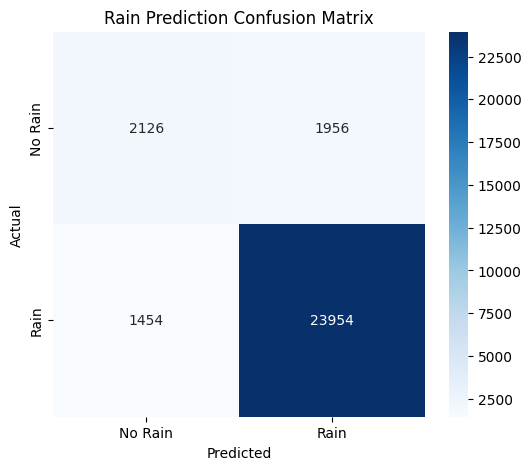

In [47]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_c_test,
    rf_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Rain', 'Rain'],
    yticklabels=['No Rain', 'Rain']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Rain Prediction Confusion Matrix")

plt.show()

# **29. Regression: Linear Regression**

In [48]:
from sklearn.linear_model import LinearRegression

linear_regression = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

linear_regression.fit(
    X_train,
    y_r_train
)

print("Linear Regression trained!")

Linear Regression trained!


# **30. Regression: Random Forest**

In [49]:
from sklearn.ensemble import RandomForestRegressor

rf_regressor = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_regressor.fit(
    X_train,
    y_r_train
)

print("Random Forest Regressor trained!")

Random Forest Regressor trained!


# **31. Regression: Gradient Boosting**

In [50]:
from sklearn.ensemble import GradientBoostingRegressor

gb_regressor = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)

gb_regressor.fit(
    X_train,
    y_r_train
)

print("Gradient Boosting Regressor trained!")

Gradient Boosting Regressor trained!


# **32. Evaluate regression models**

In [51]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

regression_models = {
    'Linear Regression': linear_regression,
    'Random Forest': rf_regressor,
    'Gradient Boosting': gb_regressor
}

regression_results = []

for name, model in regression_models.items():

    predictions = model.predict(X_test)

    mae = mean_absolute_error(
        y_r_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_r_test,
            predictions
        )
    )

    r2 = r2_score(
        y_r_test,
        predictions
    )

    regression_results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2 Score': r2
    })

regression_results_df = pd.DataFrame(
    regression_results
)

display(
    regression_results_df
    .sort_values('RMSE')
)

,Model,MAE,RMSE,R2 Score
0,Linear Regression,5.218175,8.775236,0.175568
2,Gradient Boosting,5.113570,8.817751,0.167560
1,Random Forest,5.570177,9.536447,0.026333


# **33. Select best classification model**

In [57]:
best_classification_name = (
    classification_results_df
    .sort_values('F1 Score', ascending=False)
    .iloc[0]['Model']
)

best_classification_model = (
    classification_models[best_classification_name]
)

print(
    "Best Classification Model:",
    best_classification_name
)

Best Classification Model: Gradient Boosting


# **34. Select best regression model**

In [58]:
best_regression_name = (
    regression_results_df
    .sort_values('RMSE')
    .iloc[0]['Model']
)

best_regression_model = (
    regression_models[best_regression_name]
)

print(
    "Best Regression Model:",
    best_regression_name
)

Best Regression Model: Linear Regression


# **35. Display final model results**

In [59]:
print("=" * 60)
print("FINAL MODEL SELECTION")
print("=" * 60)

print(
    "\nClassification Model:",
    best_classification_name
)

print(
    "Regression Model:",
    best_regression_name
)

print("\nClassification Results:")
display(
    classification_results_df
    .sort_values('F1 Score', ascending=False)
)

print("\nRegression Results:")
display(
    regression_results_df
    .sort_values('RMSE')
)

FINAL MODEL SELECTION

Classification Model: Gradient Boosting
Regression Model: Linear Regression

Classification Results:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Gradient Boosting,0.887386,0.928957,0.941278,0.935077,0.900559
1,Random Forest,0.884368,0.924508,0.942774,0.933552,0.891604
0,Logistic Regression,0.883655,0.928318,0.937343,0.932808,0.896204



Regression Results:


,Model,MAE,RMSE,R2 Score
0,Linear Regression,5.218175,8.775236,0.175568
2,Gradient Boosting,5.113570,8.817751,0.167560
1,Random Forest,5.570177,9.536447,0.026333


# **36. Feature importance**

,Feature,Importance
7,precipitation_hours,0.810710
11,month,0.037943
3,apparent_temperature_mean,0.020961
14,rainfall_lag_1,0.019865
15,temp_diff,0.016722
6,winddirection_10m_dominant,0.016700
4,windspeed_10m_max,0.014884
8,latitude,0.012431
12,season,0.010767
13,rolling_rainfall,0.009058


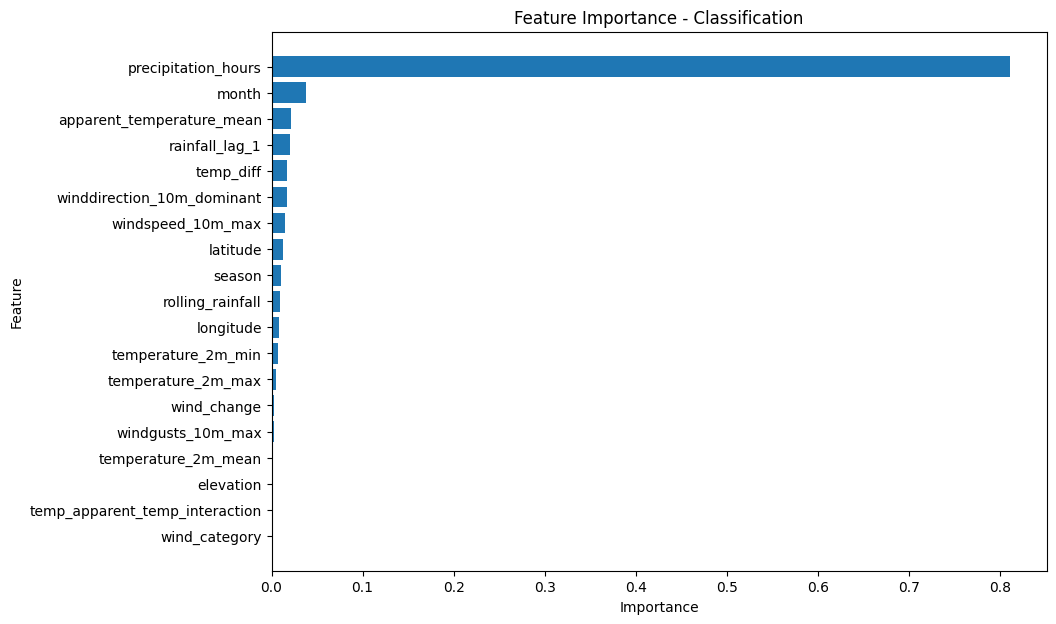

In [60]:
if hasattr(best_classification_model, 'feature_importances_'):

    importance = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': best_classification_model.feature_importances_
    })

    importance = importance.sort_values(
        'Importance',
        ascending=False
    )

    display(importance)

    plt.figure(figsize=(10, 7))

    plt.barh(
        importance['Feature'],
        importance['Importance']
    )

    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title("Feature Importance - Classification")

    plt.gca().invert_yaxis()

    plt.show()

else:
    print(
        "Selected classifier does not provide direct feature importance."
    )

# **37. Regression feature importance**

In [61]:
if hasattr(best_regression_model, 'feature_importances_'):

    regression_importance = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': best_regression_model.feature_importances_
    })

    regression_importance = regression_importance.sort_values(
        'Importance',
        ascending=False
    )

    display(regression_importance)

    plt.figure(figsize=(10, 7))

    plt.barh(
        regression_importance['Feature'],
        regression_importance['Importance']
    )

    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title("Feature Importance - Regression")

    plt.gca().invert_yaxis()

    plt.show()

else:
    print(
        "Selected regressor does not provide direct feature importance."
    )

Selected regressor does not provide direct feature importance.


# **38. Test a prediction**

In [62]:
sample = X_test.iloc[[0]]

actual_class = y_c_test.iloc[0]
actual_rainfall = y_r_test.iloc[0]

predicted_class = best_classification_model.predict(
    sample
)[0]

predicted_probability = (
    best_classification_model
    .predict_proba(sample)[0][1]
)

predicted_rainfall = (
    best_regression_model
    .predict(sample)[0]
)

print("Actual rain tomorrow:",
      "YES" if actual_class == 1 else "NO")

print(
    "Predicted rain tomorrow:",
    "YES" if predicted_class == 1 else "NO"
)

print(
    "Rain probability:",
    round(predicted_probability * 100, 2),
    "%"
)

print(
    "Actual rainfall:",
    round(actual_rainfall, 2),
    "mm"
)

print(
    "Predicted rainfall:",
    round(max(0, predicted_rainfall), 2),
    "mm"
)

Actual rain tomorrow: YES
Predicted rain tomorrow: YES
Rain probability: 90.31 %
Actual rainfall: 0.9 mm
Predicted rainfall: 2.65 mm


# **39. Create models folder**

In [67]:
os.makedirs(
    'models',
    exist_ok=True
)

print("models folder created.")

models folder created.


# **40. Save the final classification model**

In [68]:
joblib.dump(
    best_classification_model,
    'models/rain_classifier.pkl'
)

print(
    "Classification model saved:"
)

print(
    "models/rain_classifier.pkl"
)

Classification model saved:
models/rain_classifier.pkl


# **41. Save final regression model**

In [69]:
joblib.dump(
    best_regression_model,
    'models/rain_regressor.pkl'
)

print(
    "Regression model saved:"
)

print(
    "models/rain_regressor.pkl"
)

Regression model saved:
models/rain_regressor.pkl


# **42. Save feature list**

In [70]:
joblib.dump(
    feature_cols,
    'models/feature_columns.pkl'
)

print(
    "Feature list saved:"
)

print(
    "models/feature_columns.pkl"
)

Feature list saved:
models/feature_columns.pkl


# **43. Save model information**

In [71]:
model_info = {
    'classification_model': best_classification_name,
    'regression_model': best_regression_name,
    'features': feature_cols,
    'target_classification': 'rain_tomorrow',
    'target_regression': 'rainfall_amount_tomorrow'
}

joblib.dump(
    model_info,
    'models/model_info.pkl'
)

print("Model information saved!")

Model information saved!


# **44. Verify saved files**

In [72]:
print("Files inside models folder:")

for file in os.listdir('models'):
    print("-", file)

Files inside models folder:
- rain_classifier.pkl
- rain_regressor.pkl
- model_info.pkl
- feature_columns.pkl


# **45. Download the models from Colab**

In [73]:
from google.colab import files
import shutil

# Create ZIP file
shutil.make_archive(
    'SmartRain_Models',
    'zip',
    'models'
)

print("Models compressed successfully!")

Models compressed successfully!


In [74]:
files.download('SmartRain_Models.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>